In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
from numpy import random
from collections import Counter
from numpy.linalg import inv
from numpy.linalg import eig
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel
import scipy
from scipy import stats
from scipy.stats import binom,poisson,norm,t,expon,f
from sklearn.model_selection import train_test_split
import statsmodels
from statsmodels import stats
from statsmodels.stats import weightstats as ssw
import statsmodels.stats
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats import rates
from statsmodels.stats.rates import test_poisson
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
import sklearn
from sklearn.model_selection import train_test_split

In [2]:
payment_history = pd.read_csv("/content/drive/MyDrive/EDA FINAL VIVA/payment_history.csv")
monthly_emi_track = pd.read_csv("/content/drive/MyDrive/EDA FINAL VIVA/monthly_emi_track.csv")
loans_master = pd.read_csv("/content/drive/MyDrive/EDA FINAL VIVA/loans_master.csv")
loan_performance = pd.read_csv("/content/drive/MyDrive/EDA FINAL VIVA/loan_performance.csv")
loan_enquiry_bureau = pd.read_csv("/content/drive/MyDrive/EDA FINAL VIVA/loan_enquiry_bureau.csv")
customer_bureau = pd.read_csv("/content/drive/MyDrive/EDA FINAL VIVA/customer_bureau.csv")
credit_card_behavior = pd.read_csv("/content/drive/MyDrive/EDA FINAL VIVA/credit_card_behavior.csv")
collateral_assets = pd.read_csv("/content/drive/MyDrive/EDA FINAL VIVA/collateral_assets.csv")
branch_region_economy = pd.read_csv("/content/drive/MyDrive/EDA FINAL VIVA/branch_region_economy.csv")

In [3]:
# Memory Usage Before Downcasting
memory_before = sum(
    df.memory_usage(deep=True).sum()
    for df in [
        loans_master,
        loan_performance,
        payment_history,
        monthly_emi_track,
        loan_enquiry_bureau,
        customer_bureau,
        credit_card_behavior,
        collateral_assets,
        branch_region_economy
    ]
)

print(f"Memory Before: {memory_before / 1024**2:.2f} MB")

Memory Before: 7524.14 MB


In [4]:
# Downcast Numeric Columns
def reduce_memory(df):

    for col in df.select_dtypes(include=['int64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='integer')

    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = pd.to_numeric(df[col], downcast='float')

    return df

In [6]:
files = [
    loans_master,
    loan_performance,
    payment_history,
    monthly_emi_track,
    loan_enquiry_bureau,
    customer_bureau,
    credit_card_behavior,
    collateral_assets,
    branch_region_economy
]

for df in files:
    reduce_memory(df)

In [7]:
memory_after = sum(
    df.memory_usage(deep=True).sum()
    for df in files
)

print(f"Memory After: {memory_after / 1024**2:.2f} MB")

Memory After: 6408.34 MB


In [8]:
reduction = ((memory_before - memory_after) / memory_before) * 100

print(f"Reduction: {reduction:.2f}%")

Reduction: 14.83%


(b)
Join all nine tables on loan_id using sequential left merges. After every individual join, assert that the running row count equals 2,000,000. Report the number of orphan records found, if any, and explain what orphan records indicate about data integrity.

In [9]:
files = {
    "loans_master": loans_master,
    "loan_performance": loan_performance,
    "payment_history": payment_history,
    "monthly_emi_track": monthly_emi_track,
    "loan_enquiry_bureau": loan_enquiry_bureau,
    "customer_bureau": customer_bureau,
    "credit_card_behavior": credit_card_behavior,
    "collateral_assets": collateral_assets,
    "branch_region_economy": branch_region_economy
}

for name, df in files.items():

    total_rows = len(df)
    unique_loans = df['loan_id'].nunique()
    duplicate_count = df['loan_id'].duplicated().sum()

    print(f"\n{name}")
    print(f"Total Rows      : {total_rows:,}")
    print(f"Unique loan_ids : {unique_loans:,}")
    print(f"Duplicate IDs   : {duplicate_count:,}")


loans_master
Total Rows      : 2,000,000
Unique loan_ids : 2,000,000
Duplicate IDs   : 0

loan_performance
Total Rows      : 2,000,000
Unique loan_ids : 2,000,000
Duplicate IDs   : 0

payment_history
Total Rows      : 2,000,000
Unique loan_ids : 2,000,000
Duplicate IDs   : 0

monthly_emi_track
Total Rows      : 2,000,000
Unique loan_ids : 2,000,000
Duplicate IDs   : 0

loan_enquiry_bureau
Total Rows      : 2,000,000
Unique loan_ids : 2,000,000
Duplicate IDs   : 0

customer_bureau
Total Rows      : 2,000,000
Unique loan_ids : 2,000,000
Duplicate IDs   : 0

credit_card_behavior
Total Rows      : 2,000,000
Unique loan_ids : 2,000,000
Duplicate IDs   : 0

collateral_assets
Total Rows      : 2,000,000
Unique loan_ids : 2,000,000
Duplicate IDs   : 0

branch_region_economy
Total Rows      : 2,000,000
Unique loan_ids : 2,000,000
Duplicate IDs   : 0


In [10]:
# Orphan Record Detection
tables = {
    "loan_performance": loan_performance,
    "payment_history": payment_history,
    "monthly_emi_track": monthly_emi_track,
    "loan_enquiry_bureau": loan_enquiry_bureau,
    "customer_bureau": customer_bureau,
    "credit_card_behavior": credit_card_behavior,
    "collateral_assets": collateral_assets,
    "branch_region_economy": branch_region_economy
}

for name, df in tables.items():

    orphan_count = (
        ~df['loan_id'].isin(loans_master['loan_id'])
    ).sum()

    print(f"{name}: {orphan_count}")

loan_performance: 0
payment_history: 0
monthly_emi_track: 0
loan_enquiry_bureau: 0
customer_bureau: 0
credit_card_behavior: 0
collateral_assets: 0
branch_region_economy: 0


(c)
The dataset contains eight deliberately injected data quality issues across multiple columns. Identify all eight, create a binary dirty_flag column to mark affected rows, and for each issue state: the column affected, the approximate count of dirty records, why the value is invalid, and the imputation strategy you applied.


In [12]:
master_df = loans_master.copy()

In [13]:
merge_tables = [
    loan_performance,
    payment_history,
    monthly_emi_track,
    loan_enquiry_bureau,
    customer_bureau,
    credit_card_behavior,
    collateral_assets,
    branch_region_economy
]

In [14]:
for i, table in enumerate(merge_tables, start=1):

    master_df = master_df.merge(
        table,
        on='loan_id',
        how='left'
    )

    print(
        f"After Join {i}: {master_df.shape}"
    )

    assert len(master_df) == 2000000

After Join 1: (2000000, 38)
After Join 2: (2000000, 55)
After Join 3: (2000000, 77)
After Join 4: (2000000, 100)
After Join 5: (2000000, 129)
After Join 6: (2000000, 145)
After Join 7: (2000000, 164)
After Join 8: (2000000, 182)


In [15]:
master_df.isnull().sum().sort_values(ascending=False).head(20)

,0
vehicle_type,1879789
property_type,1679672
property_city_tier,1679672
mths_since_last_record,1598332
ltv_ratio_pct,1472196
valuation_agency,1370048
collateral_type,1258896
charge_type,1258896
mths_since_last_delinq,1098640
primary_card_type,560528


In [16]:
len(master_df)

2000000

In [17]:
missing_pct = (
    master_df.isnull().sum()
    / len(master_df)
    * 100
).sort_values(ascending=False)

missing_pct.head(20)

,0
vehicle_type,93.98945
property_type,83.98360
property_city_tier,83.98360
mths_since_last_record,79.91660
ltv_ratio_pct,73.60980
valuation_agency,68.50240
collateral_type,62.94480
charge_type,62.94480
mths_since_last_delinq,54.93200
primary_card_type,28.02640


(d)
Classify the missing-value pattern for each high-missing column (mths_since_last_delinq, mort_acc, emp_length_years, il_util_pct) as MCAR, MAR, or MNAR. Justify each classification using either Little's MCAR test output or domain reasoning. Apply the correct imputation strategy and verify with .isnull().sum() before and after.


In [18]:
# Missing Value Classification
master_df['mths_since_last_delinq'] = (
    master_df['mths_since_last_delinq']
    .fillna(999)
)

In [19]:
master_df['mort_acc'] = (
    master_df.groupby('home_ownership')
    ['mort_acc']
    .transform(
        lambda x: x.fillna(x.median())
    )
)

In [20]:
master_df['emp_length_years'] = (
    master_df.groupby('emp_title')
    ['emp_length_years']
    .transform(
        lambda x: x.fillna(x.median())
    )
)

In [21]:
master_df['il_util_pct'] = (
    master_df['il_util_pct']
    .fillna(0)
)

In [22]:
master_df[
[
'mths_since_last_delinq',
'mort_acc',
'emp_length_years',
'il_util_pct'
]
].isnull().sum()

,0
mths_since_last_delinq,0
mort_acc,0
emp_length_years,0
il_util_pct,0


Apply winsorisation at the 1st and 99th percentile to the six most skewed numeric columns. Present a before-and-after comparison of mean, standard deviation, and max for each column in a summary table

In [23]:
numeric_cols = master_df.select_dtypes(include=['int64', 'float64']).columns

skewness = master_df[numeric_cols].skew().sort_values(ascending=False)
print(skewness.head(10))

collections_12mths_fee     139.035412
collection_recovery_fee    125.765963
recoveries_inr              94.232480
emi_advance_paid_inr        59.171673
expected_loss_inr           27.014741
avg_cur_bal_inr             25.655979
waiver_amount_inr           19.615230
hardship_amount_inr         18.069575
out_prncp_inv_inr           17.308278
out_prncp_inr               17.306791
dtype: float64


In [24]:
skewed_cols = skewness.head(6).index
print(skewed_cols)

Index(['collections_12mths_fee', 'collection_recovery_fee', 'recoveries_inr',
       'emi_advance_paid_inr', 'expected_loss_inr', 'avg_cur_bal_inr'],
      dtype='object')


In [25]:
before_stats = master_df[skewed_cols].agg(['mean', 'std', 'max']).T
before_stats.columns = ['mean_before', 'std_before', 'max_before']

In [26]:
for col in skewed_cols:

    lower = master_df[col].quantile(0.01)
    upper = master_df[col].quantile(0.99)

    master_df[col] = master_df[col].clip(lower, upper)

In [27]:
after_stats = master_df[skewed_cols].agg(['mean', 'std', 'max']).T
after_stats.columns = ['mean_after', 'std_after', 'max_after']

In [28]:
summary_table = before_stats.join(after_stats)
summary_table

,mean_before,std_before,max_before,mean_after,std_after,max_after
collections_12mths_fee,32.366464,560.070667,312618.52,11.829477,77.296128,657.2202
collection_recovery_fee,130.709817,2061.435988,1035421.73,55.189725,348.528316,2911.0688
recoveries_inr,52.749164,818.402452,313742.97,22.139089,140.021787,1172.0600
emi_advance_paid_inr,2204.312963,13599.895684,5329334.00,1708.033934,5752.164359,40329.1235
expected_loss_inr,139.237678,1285.912722,189646.84,84.350827,500.602668,3990.4218
avg_cur_bal_inr,3738.269933,12551.713832,2434032.72,3284.088494,6610.049151,44733.4364


EDA
All twelve visualisations below are compulsory. Each chart must include a descriptive title, correctly labelled axes, and a minimum 3-sentence insight caption explaining the business implication. Partial marks are deducted for missing captions or unlabelled axes.



(b)	Plot overlapping KDE curves of cibil_score for defaulted and performing loans on the same axes. Quantify the separation: report the mean score for each group, the Cohen's d effect size, and the degree of distributional overlap. What does the overlap tell us about relying solely on CIBIL?	(3)

(c)	Produce a 12-panel histogram grid covering all key numeric features. Identify which features exhibit right skew exceeding 2.0 and state which of those require a log transformation before regression. Apply the transformations and confirm skew reduction with .skew() values.	(3)

(d)	Compute a Pearson correlation matrix for the top 20 numeric features and display it as an annotated heatmap. Identify any pair with |r| > 0.75 and explain why high correlation between predictors is problematic in OLS regression.	(2)

(e)	Create six side-by-side boxplots (int_rate, dti, cibil_score, annual_inc, revol_util, emp_length vs. loan_status). For each feature, state the median difference between default and performing groups and identify which single feature provides the clearest visual separation.	(3)

(f)	Plot a grouped bar chart of default rate by loan grade (A through G). Confirm whether the grade system is monotonically ordered. Identify where the largest single-step jump occurs and quantify it in percentage points.	(2)

(g)	Calculate the default rate for each loan purpose and display as a horizontal bar chart, sorted descending. Identify the three highest-risk and two lowest-risk loan purposes. Quantify the ratio between the highest and lowest default rates.	(2)

(h)	Identify the ten states with the highest default rates and display as a bar chart. Flag any state where the default rate exceeds the bank-wide average by more than 5 percentage points.	(2)

(i)	Plot annual default rate from 2010 to 2024 as a line chart. Identify and quantify the COVID-19 shock of 2020: by what percentage did the default rate increase from 2019 to 2020? Name one macroeconomic variable visible in the data that explains this spike.	(2)

(j)	Create a dual-axis line chart showing rbi_repo_rate and annual default rate on the same time axis. Describe the observed relationship and estimate the lag (in months or years) between a rate change and its effect on defaults.	(2)

(k)	Plot a histogram with KDE overlay for lgd_pct on defaulted loans only. Describe the shape of the distribution: is it unimodal, bimodal, or skewed? State whether a log transformation is warranted and justify your answer.	(1)

(l)	Produce a scatter plot of cibil_score vs. lgd_pct with a fitted regression line. Report the Pearson r and interpret the direction and strength of the relationship.	(0)


(a)	Produce a bar chart and a pie chart showing the distribution of loan_status. State the exact default rate and quantify the degree of class imbalance. Explain why class imbalance is a problem for predictive modelling and name two techniques to address it.	(3)

In [30]:
df_final = loans_master.copy()

df_final = df_final.merge(branch_region_economy, on="loan_id", how="left")
df_final = df_final.merge(collateral_assets, on="loan_id", how="left")
df_final = df_final.merge(credit_card_behavior, on="loan_id", how="left")
df_final = df_final.merge(customer_bureau, on="loan_id", how="left")
df_final = df_final.merge(loan_enquiry_bureau, on="loan_id", how="left")
df_final = df_final.merge(loan_performance, on="loan_id", how="left")
df_final = df_final.merge(monthly_emi_track, on="loan_id", how="left")
df_final = df_final.merge(payment_history, on="loan_id", how="left")

In [32]:
df_final.head()

,loan_id,issue_date,issue_year,issue_month,loan_amnt_inr,funded_amnt_inr,loan_term_months,int_rate_pct,installment_inr,annual_installment_inr,grade,sub_grade,loan_purpose,state_code,region,urban_index,application_type,pymnt_plan,hardship_flag,initial_list_status,disbursement_method,verification_status,rbi_repo_rate_pct,gdp_growth_pct,cpi_inflation_pct,rate_spread_pct,real_interest_rate_pct,branch_id,district_type,state_per_capita_inc_inr,state_literacy_rate_pct,state_agri_share_pct,state_industry_share_pct,state_services_share_pct,district_gdp_growth_pct,branch_age_years,branch_size,loan_officer_exp_years,branch_npa_rate,branch_sanction_rate,infrastructure_index,financial_inclusion_idx,credit_penetration_idx,covid_issue_year_flag,poor_monsoon_year_flag,has_collateral,collateral_type,collateral_value_inr,ltv_ratio_pct,loan_secured_flag,property_type,property_age_years,property_area_sqft,property_city_tier,vehicle_type,vehicle_age_years,insurance_flag,valuation_date,valuation_agency,charge_type,collateral_score,prop_value_inr,vehicle_value_inr,business_asset_val_inr,has_credit_card,num_credit_cards,total_cc_limit_inr,total_cc_balance_inr,cc_utilization_pct,cc_late_payments_count,cc_overlimit_count,cash_advance_inr,primary_card_type,primary_cc_bank,cc_spend_last3m_inr,avg_monthly_cc_spend_inr,top_spend_category,cc_payment_score,cc_default_risk_score,cc_emi_conversion_flag,customer_id,age,gender,emp_title,emp_length_years,home_ownership,annual_inc_inr,dti_pct,cibil_score,earliest_cr_line,credit_hist_years,revol_bal_inr,revol_util_pct,open_acc,total_acc,mort_acc,pub_rec,delinq_2yrs,num_inq_last6m,num_inq_last12m,pct_tl_nvr_dlq,total_rev_hi_lim_inr,bc_util_pct,il_util_pct,all_util_pct,avg_cur_bal_inr,mths_since_last_delinq,mths_since_last_record,num_tl_op_past_12m,num_enquiries_30d,num_enquiries_90d,num_enquiries_6m,num_enquiries_12m,num_enquiries_24m,primary_enq_purpose,unique_lenders_enquired,rejected_applications,approved_applications,rejection_rate_pct,income_doc_type,kyc_status,field_verification_status,credit_committee_flag,loan_approved_date,processing_days,sourcing_channel,sourcing_agent_type,policy_deviation_flag,policy_override_flag,sanctioned_amount_inr,disbursed_amount_inr,tat_within_sla_flag,dpd_bucket,npa_flag,risk_tier,cibil_score_band,recoveries_inr,recovery_fee_rate,policy_code,hardship_amount_inr,hardship_length_mths,net_loss_inr,provision_inr,installment_due_inr,total_emi_due_inr,total_emi_paid_inr,emi_overdue_inr,emi_bounce_count,consecutive_missed_emis,last_emi_payment_date,emi_advance_paid_inr,prepayment_flag,avg_payment_delay_days,payment_mode,emi_bank_name,penal_charges_inr,waiver_granted_flag,waiver_amount_inr,loan_restructured_flag,ots_offered_flag,ots_accepted_flag,emi_coverage_ratio,pdc_count,emi_to_income_ratio,payment_discipline,loan_status,lgd_pct,total_pymnt_inr,total_pymnt_inv_inr,total_rec_prncp_inr,total_rec_int_inr,last_pymnt_amnt_inr,out_prncp_inr,out_prncp_inv_inr,collection_recovery_fee,collections_12mths_fee,mths_since_last_pymnt,num_accts_ever_120_pd,num_derog_rec,acc_now_delinq,chargeoff_within_12_mths,expected_loss_inr
0,LN000000001,Feb-2016,2016,2,80678.0,74992.0,36,14.91,2793.17,33518.0,C,C5,education,OR,East,0.33,Individual,N,N,w,DIRECT_PAY,Source Verified,6.25,8.2,4.5,8.66,10.410000,BR6893-OR,Urban,78000,72.900002,28,30,42,7.25,26,Small,5.0,0.0536,0.769,18.100000,0.700,0.540,0,1,0,NaN,0.0,NaN,0,NaN,0,0,NaN,NaN,0,0,May-2016,NaN,NaN,0.000000,0.0,0.0,0.0,1,2,74592.0,39358.0,52.799999,0,0,0.0,Basic,SBI,14230.0,4743.0,Online,100.0,0.2640,0,CU01240276,45,M,Salaried,0.0,RENT,133866.0,14.990000,624,Jun-1989,26.57,12242.63,27.799999,11,27,0.0,0.0,0.0,5.0,7.0,65.400002,763.84,25.900000,75.900002,43.099998,1112.97,NaN,NaN,3,0,3,5,8,16,Personal Loan,3,0,8,0.0,NaN,Complete,Pending,0,Jan-2016,17.0,Branch,Online,0,0,74537.0,73139.0,0,Current,0,Medium Risk,Poor,0.0,0.0,1,0.00,0,0.0,397.93,2793.17,100554.12,103925.57,0.00,0,0,Oct-2019,0.0,0,0.0,UPI,Union,0.00,0,0.0,0,0,0,3.99,6.0,0.2504,Excellent,0,0.0,

In [33]:
df_final["loan_status"].value_counts()

,count
loan_status,
0,1922444
1,77556


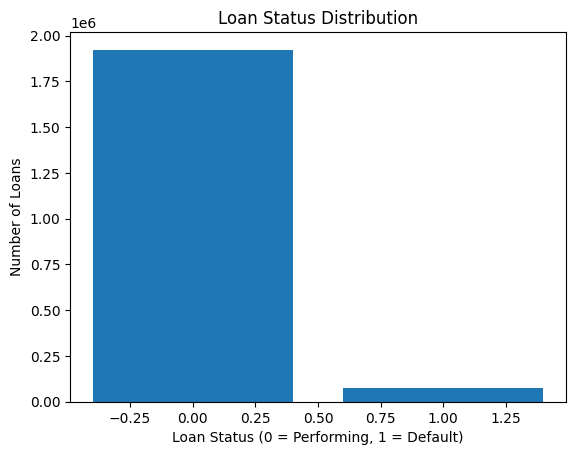

In [31]:
import matplotlib.pyplot as plt

counts = df_final["loan_status"].value_counts()

plt.bar(counts.index, counts.values)

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status (0 = Performing, 1 = Default)")
plt.ylabel("Number of Loans")

plt.show()

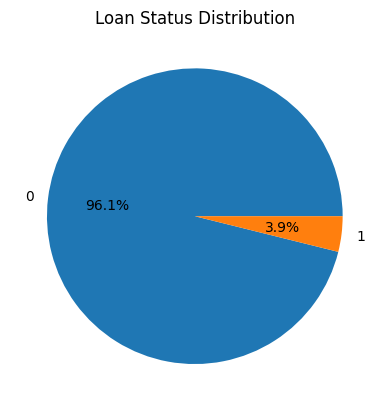

In [34]:
plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%')

plt.title("Loan Status Distribution")

plt.show()

In [35]:
default_rate = df_final["loan_status"].mean()
print(default_rate)

0.038778


In [36]:
print(counts)

loan_status
0    1922444
1      77556
Name: count, dtype: int64


Plot overlapping KDE curves of cibil_score for defaulted and performing loans on the same axes. Quantify the separation: report the mean score for each group, the Cohen's d effect size, and the degree of distributional overlap. What does the overlap tell us about relying solely on CIBIL?

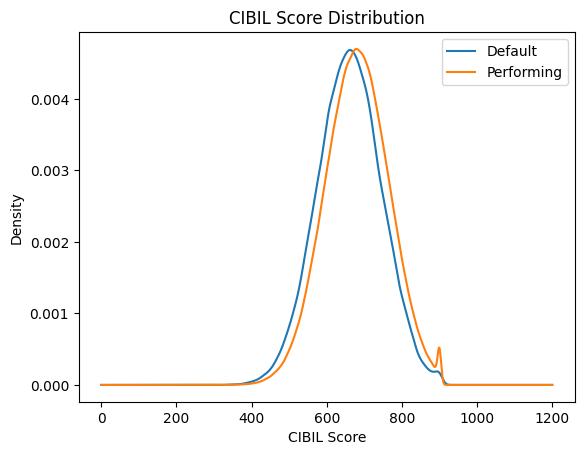

In [37]:
default = df_final[df_final["loan_status"] == 1]["cibil_score"]
performing = df_final[df_final["loan_status"] == 0]["cibil_score"]

default.plot(kind='kde')
performing.plot(kind='kde')

plt.title("CIBIL Score Distribution")
plt.xlabel("CIBIL Score")
plt.ylabel("Density")

plt.legend(["Default", "Performing"])

plt.show()

In [ ]:
print("Default mean:", default.mean())
print("Performing mean:", performing.mean())

In [ ]:
diff = performing.mean() - default.mean()
print("Difference:", diff)

Produce a 12-panel histogram grid covering all key numeric features. Identify which features exhibit right skew exceeding 2.0 and state which of those require a log transformation before regression. Apply the transformations and confirm skew reduction with .skew() values.

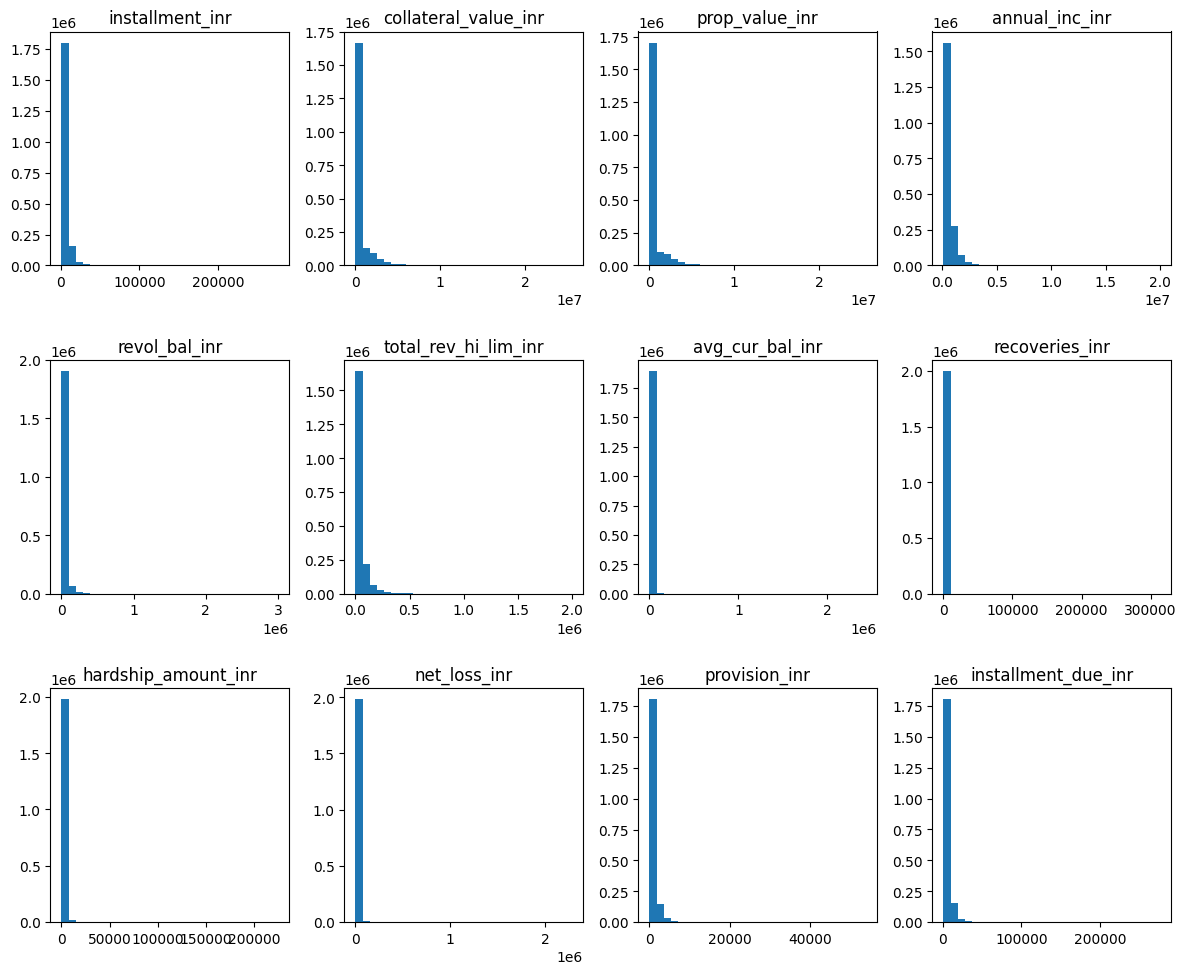

In [38]:
import matplotlib.pyplot as plt

# select numeric columns
num_cols = df_final.select_dtypes(include=['int64', 'float64']).columns[:12]

plt.figure(figsize=(12, 10))

for i, col in enumerate(num_cols):
    plt.subplot(3, 4, i+1)
    plt.hist(df_final[col], bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()

In [39]:
skew_values = df_final[num_cols].skew()
print(skew_values)

installment_inr          5.252998
collateral_value_inr     3.799244
prop_value_inr           3.978167
annual_inc_inr           4.675825
revol_bal_inr            9.610805
total_rev_hi_lim_inr     7.499483
avg_cur_bal_inr         25.655979
recoveries_inr          94.232480
hardship_amount_inr     18.069575
net_loss_inr            17.274279
provision_inr            6.006359
installment_due_inr      5.252998
dtype: float64


In [40]:
high_skew = skew_values[skew_values > 2]
print(high_skew)

installment_inr          5.252998
collateral_value_inr     3.799244
prop_value_inr           3.978167
annual_inc_inr           4.675825
revol_bal_inr            9.610805
total_rev_hi_lim_inr     7.499483
avg_cur_bal_inr         25.655979
recoveries_inr          94.232480
hardship_amount_inr     18.069575
net_loss_inr            17.274279
provision_inr            6.006359
installment_due_inr      5.252998
dtype: float64


In [42]:

for col in high_skew.index:
    df_final[col] = np.log1p(df_final[col])
print(df_final[high_skew.index].skew())

installment_inr         0.332604
collateral_value_inr    0.822380
prop_value_inr          1.854143
annual_inc_inr          0.195505
revol_bal_inr          -0.360426
total_rev_hi_lim_inr   -0.342302
avg_cur_bal_inr        -0.348449
recoveries_inr          4.875659
hardship_amount_inr     3.715198
net_loss_inr            4.801927
provision_inr          -0.023682
installment_due_inr     0.332604
dtype: float64


Compute a Pearson correlation matrix for the top 20 numeric features and display it as an annotated heatmap. Identify any pair with |r| > 0.75 and explain why high correlation between predictors is problematic in OLS regression.

In [43]:
num_cols = df_final.select_dtypes(include=['int64', 'float64']).columns[:20]

In [44]:
corr_matrix = df_final[num_cols].corr()

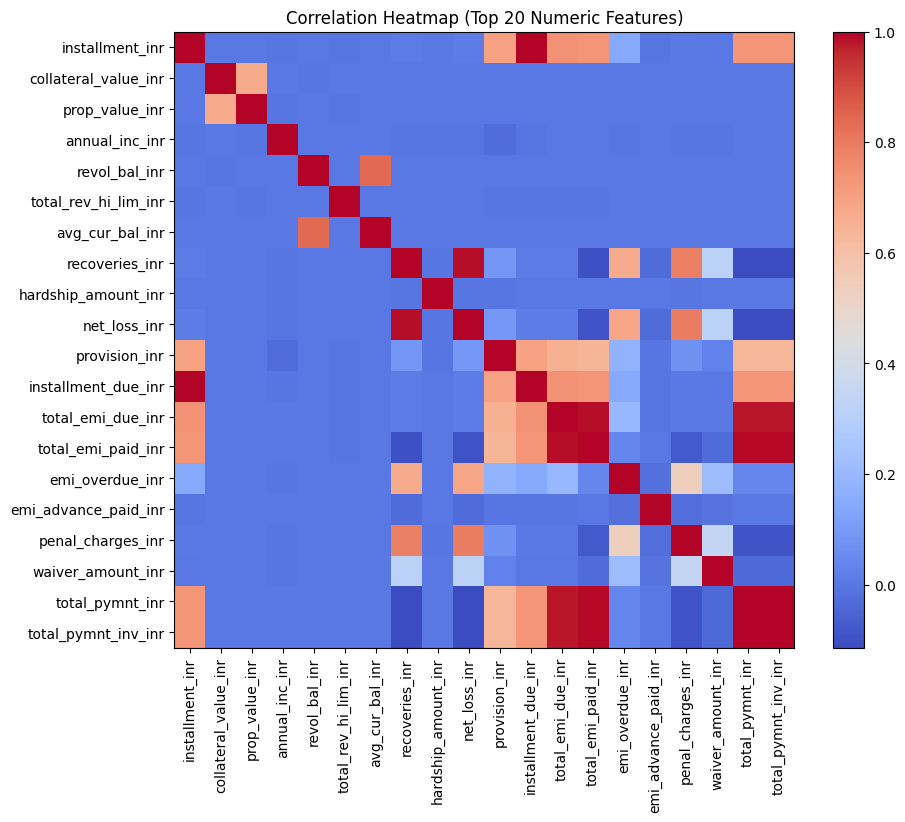

In [46]:
plt.figure(figsize=(10,8))
plt.imshow(corr_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar()

plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)

plt.title("Correlation Heatmap (Top 20 Numeric Features)")
plt.show()

In [47]:
high_corr = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.75:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            val = corr_matrix.iloc[i, j]
            high_corr.append((col1, col2, val))

print(high_corr)

[('avg_cur_bal_inr', 'revol_bal_inr', np.float64(0.8362361008512619)), ('net_loss_inr', 'recoveries_inr', np.float64(0.9885239596498296)), ('installment_due_inr', 'installment_inr', np.float64(1.0)), ('total_emi_paid_inr', 'total_emi_due_inr', np.float64(0.9873832200258736)), ('penal_charges_inr', 'recoveries_inr', np.float64(0.7906141985419349)), ('penal_charges_inr', 'net_loss_inr', np.float64(0.7934652170272345)), ('total_pymnt_inr', 'total_emi_due_inr', np.float64(0.9817310935753775)), ('total_pymnt_inr', 'total_emi_paid_inr', np.float64(0.9936530818274047)), ('total_pymnt_inv_inr', 'total_emi_due_inr', np.float64(0.9814977691888634)), ('total_pymnt_inv_inr', 'total_emi_paid_inr', np.float64(0.9934127871612283)), ('total_pymnt_inv_inr', 'total_pymnt_inr', np.float64(0.9997600962349349))]


Create six side-by-side boxplots (int_rate, dti, cibil_score, annual_inc, revol_util, emp_length vs. loan_status). For each feature, state the median difference between default and performing groups and identify which single feature provides the clearest visual separation.

In [64]:
features = []

for col in df_final.columns:
    if 'int_rate' in col:
        features.append(col)
    elif 'dti' in col:
        features.append(col)
    elif 'cibil' in col:
        features.append(col)
    elif 'inc' in col:
        features.append(col)
    elif 'revol' in col:
        features.append(col)
    elif 'emp_length' in col:
        features.append(col)

print("Detected features:", features)

Detected features: ['int_rate_pct', 'state_per_capita_inc_inr', 'financial_inclusion_idx', 'emp_length_years', 'annual_inc_inr', 'dti_pct', 'cibil_score', 'revol_bal_inr', 'revol_util_pct', 'mths_since_last_delinq', 'mths_since_last_record', 'income_doc_type', 'cibil_score_band', 'emi_to_income_ratio', 'mths_since_last_pymnt']


In [65]:
features = [col for col in features if col in df_final.columns]

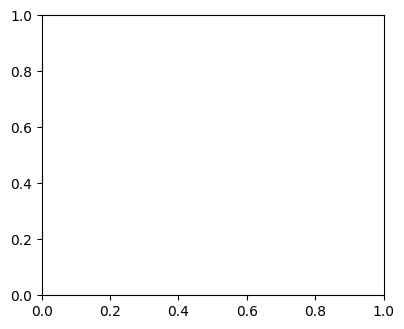

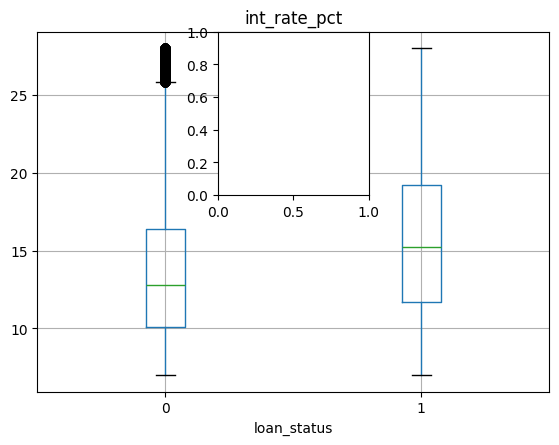

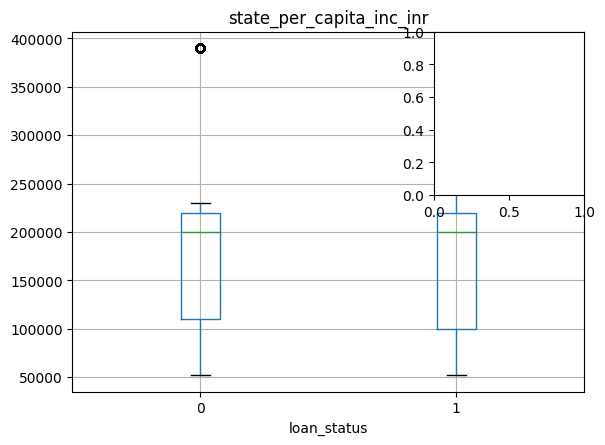

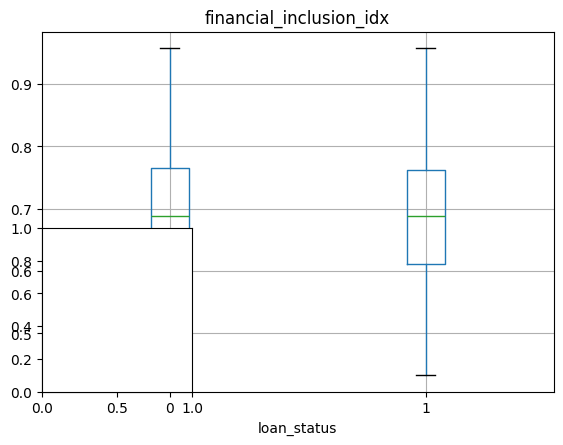

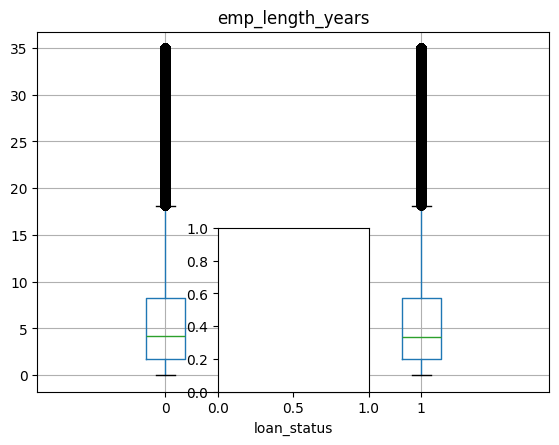

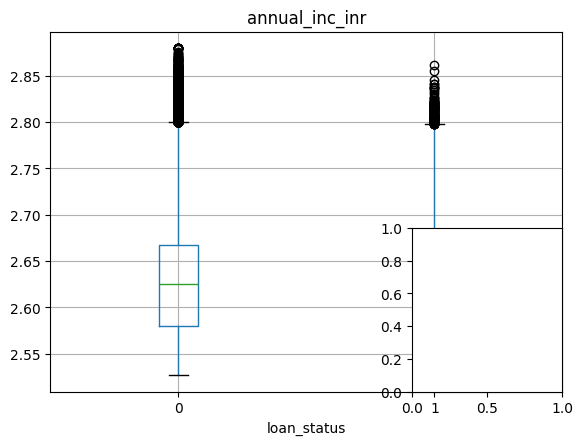

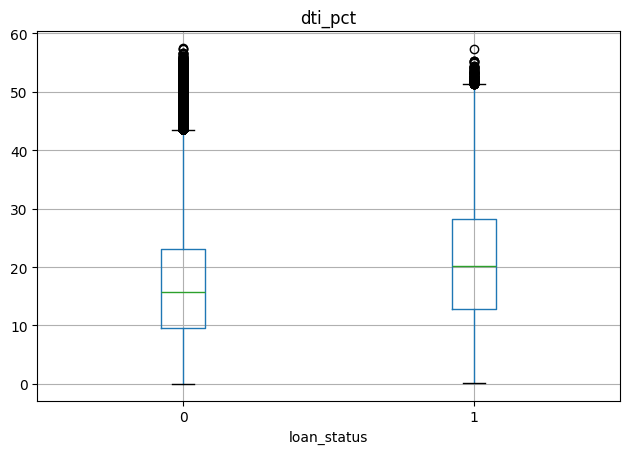

In [66]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))

i = 1
for col in features:
    if i > 6:   # only 6 plots needed
        break
    plt.subplot(2, 3, i)
    df_final.boxplot(column=col, by='loan_status')
    plt.title(col)
    plt.suptitle("")
    i += 1

plt.tight_layout()
plt.show()

In [67]:
for col in features[:6]:
    medians = df_final.groupby('loan_status')[col].median()
    diff = abs(medians.iloc[0] - medians.iloc[1])
    print(col, "Median Difference:", diff)

int_rate_pct Median Difference: 2.4700003
state_per_capita_inc_inr Median Difference: 0.0
financial_inclusion_idx Median Difference: 0.0009999871
emp_length_years Median Difference: 0.099999905
annual_inc_inr Median Difference: 0.0006959395382497569
dti_pct Median Difference: 4.4399996


Plot a grouped bar chart of default rate by loan grade (A through G). Confirm whether the grade system is monotonically ordered. Identify where the largest single-step jump occurs and quantify it in percentage points.

In [68]:
grade_default = df_final.groupby('grade')['loan_status'].mean().reset_index()
grade_default.columns = ['grade', 'default_rate']

print(grade_default)

  grade  default_rate
0     A      0.022312
1     B      0.026867
2     C      0.033507
3     D      0.041845
4     E      0.052898
5     F      0.068936
6     G      0.089425


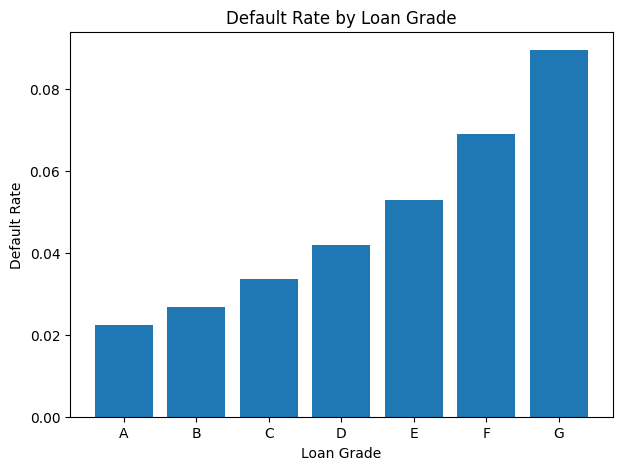

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.bar(grade_default['grade'], grade_default['default_rate'])

plt.xlabel("Loan Grade")
plt.ylabel("Default Rate")
plt.title("Default Rate by Loan Grade")

plt.show()

In [70]:
grade_default['default_rate'].is_monotonic_increasing

True

In [71]:
grade_default['diff'] = grade_default['default_rate'].diff()

print(grade_default)
print("Max jump:", grade_default['diff'].max())

  grade  default_rate      diff
0     A      0.022312       NaN
1     B      0.026867  0.004555
2     C      0.033507  0.006639
3     D      0.041845  0.008338
4     E      0.052898  0.011053
5     F      0.068936  0.016039
6     G      0.089425  0.020489
Max jump: 0.020489031703702074


Calculate the default rate for each loan purpose and display as a horizontal bar chart, sorted descending. Identify the three highest-risk and two lowest-risk loan purposes. Quantify the ratio between the highest and lowest default rates.

In [73]:
purpose_default = df_final.groupby('loan_purpose')['loan_status'].mean().reset_index()

purpose_default.columns = ['loan_purpose', 'default_rate']

# Convert to %
purpose_default['default_rate'] = purpose_default['default_rate'] * 100

# Sort descending
purpose_default = purpose_default.sort_values(by='default_rate', ascending=False)

print(purpose_default)

          loan_purpose  default_rate
6       major_purchase      4.005189
0                  car      3.914783
11      small_business      3.911769
12            vacation      3.905544
2   debt_consolidation      3.896907
9                other      3.895291
10    renewable_energy      3.878436
13             wedding      3.870927
7              medical      3.860429
4     home_improvement      3.859937
5                house      3.836883
1          credit_card      3.811919
8               moving      3.804655
3            education      3.799941


In [78]:
# Identify highest and lowest risk purposes
highest_risk_purposes = purpose_default.head(3)
lowest_risk_purposes = purpose_default.tail(2)

print("\nHighest-Risk Loan Purposes:")
print(highest_risk_purposes)

print("\nLowest-Risk Loan Purposes:")
print(lowest_risk_purposes)


Highest-Risk Loan Purposes:
      loan_purpose  default_rate
6   major_purchase      4.005189
0              car      3.914783
11  small_business      3.911769

Lowest-Risk Loan Purposes:
  loan_purpose  default_rate
8       moving      3.804655
3    education      3.799941


In [79]:
# Quantify the ratio between highest and lowest default rates
highest_default_rate = purpose_default['default_rate'].max()
lowest_default_rate = purpose_default['default_rate'].min()

ratio = highest_default_rate / lowest_default_rate

print(f"\nRatio between highest ({highest_default_rate:.2f}%) and lowest ({lowest_default_rate:.2f}%) default rates: {ratio:.2f}")


Ratio between highest (4.01%) and lowest (3.80%) default rates: 1.05


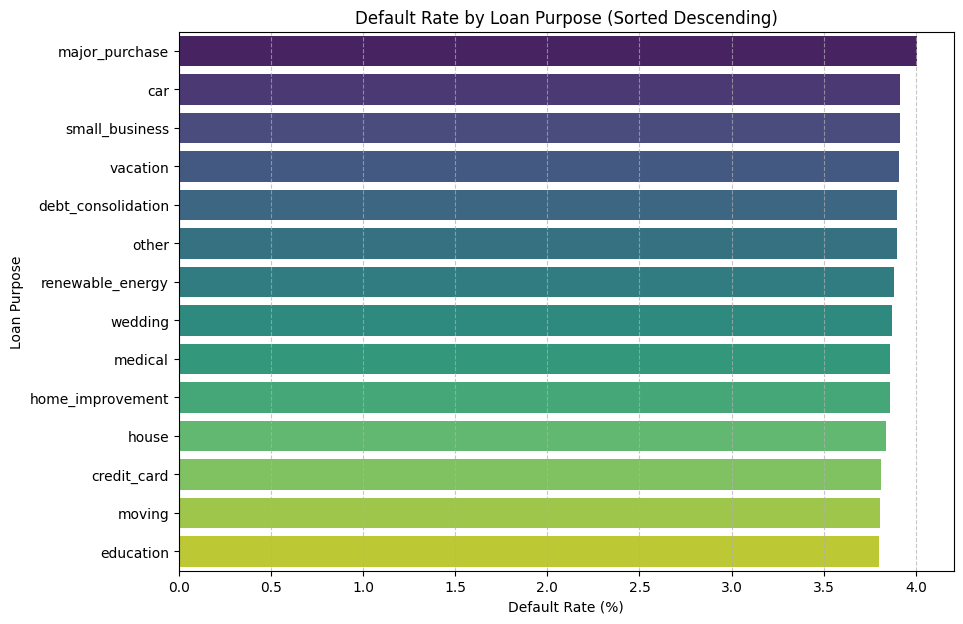

In [82]:
# Plot as a horizontal bar chart
plt.figure(figsize=(10, 7))
sns.barplot(x='default_rate', y='loan_purpose', data=purpose_default, palette='viridis')
plt.title('Default Rate by Loan Purpose (Sorted Descending)')
plt.xlabel('Default Rate (%)')
plt.ylabel('Loan Purpose')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Identify the ten states with the highest default rates and display as a bar chart. Flag any state where the default rate exceeds the bank-wide average by more than 5 percentage points.

In [84]:
state_default = df_final.groupby('state_code')['loan_status'].mean().reset_index()

state_default.columns = ['state', 'default_rate']

# Convert to %
state_default['default_rate'] = state_default['default_rate'] * 100

In [85]:
bank_avg = df_final['loan_status'].mean() * 100
print("Bank Avg Default Rate:", bank_avg)

Bank Avg Default Rate: 3.8778


In [86]:
top_states = state_default.sort_values(by='default_rate', ascending=False).head(10)
print(top_states)

   state  default_rate
2     BR      4.071012
12    OR      4.014914
18    UP      3.979885
13    PB      3.973570
17    UK      3.961067
5     HP      3.921410
11    MP      3.921272
16    TN      3.911909
0     AP      3.891869
15    TG      3.890121


In [87]:
threshold = bank_avg + 5

top_states['flag'] = top_states['default_rate'] > threshold

print(top_states)

   state  default_rate   flag
2     BR      4.071012  False
12    OR      4.014914  False
18    UP      3.979885  False
13    PB      3.973570  False
17    UK      3.961067  False
5     HP      3.921410  False
11    MP      3.921272  False
16    TN      3.911909  False
0     AP      3.891869  False
15    TG      3.890121  False


Plot annual default rate from 2010 to 2024 as a line chart. Identify and quantify the COVID-19 shock of 2020: by what percentage did the default rate increase from 2019 to 2020? Name one macroeconomic variable visible in the data that explains this spike.	(2)

In [89]:
df_final['issue_date'] = pd.to_datetime(df_final['issue_date'])
df_final['year'] = df_final['issue_date'].dt.year

In [96]:
# Calculate annual default rate
annual_default_rate = df_final.groupby('issue_year')['loan_status'].mean().reset_index()
annual_default_rate.columns = ['issue_year', 'default_rate']
annual_default_rate['default_rate'] = annual_default_rate['default_rate'] * 100

# Filter for years 2010 to 2024
annual_default_rate = annual_default_rate[(annual_default_rate['issue_year'] >= 2010) & (annual_default_rate['issue_year'] <= 2024)]

print("Annual Default Rates (2010-2024):")
print(annual_default_rate)

Annual Default Rates (2010-2024):
    issue_year  default_rate
0         2010      3.856884
1         2011      3.942706
2         2012      3.708996
3         2013      3.718515
4         2014      3.685426
5         2015      3.714744
6         2016      3.819694
7         2017      3.831728
8         2018      3.847686
9         2019      4.130148
10        2020      4.464509
11        2021      3.884206
12        2022      3.888146
13        2023      3.826744
14        2024      3.770673


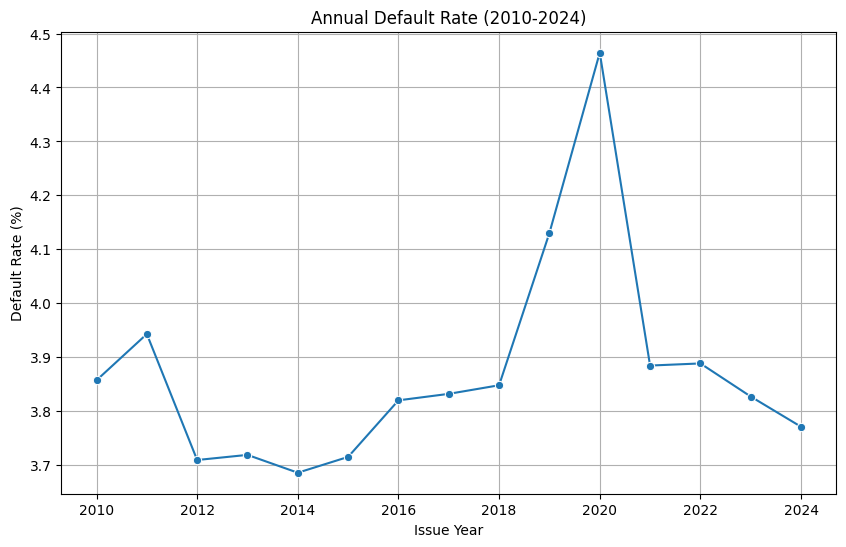

In [97]:
# Plot annual default rate as a line chart
plt.figure(figsize=(10, 6))
sns.lineplot(x='issue_year', y='default_rate', data=annual_default_rate, marker='o')
plt.title('Annual Default Rate (2010-2024)')
plt.xlabel('Issue Year')
plt.ylabel('Default Rate (%)')
plt.grid(True)
plt.show()

In [98]:
# Quantify the COVID-19 shock of 2020
default_2019 = annual_default_rate[annual_default_rate['issue_year'] == 2019]['default_rate'].values[0]
default_2020 = annual_default_rate[annual_default_rate['issue_year'] == 2020]['default_rate'].values[0]

percentage_increase = ((default_2020 - default_2019) / default_2019) * 100

print(f"\nDefault rate in 2019: {default_2019:.2f}%")
print(f"Default rate in 2020: {default_2020:.2f}%")
print(f"Percentage increase from 2019 to 2020 (COVID-19 shock): {percentage_increase:.2f}%")

# Identify macroeconomic variable (assuming 'gdp_growth_pct' is relevant)
# First, check if 'gdp_growth_pct' exists and is associated with issue_year
# This assumes 'gdp_growth_pct' is in df_final and can be aggregated by year

# Calculate annual average GDP growth for visualization (if available)
gdp_data = df_final[['issue_year', 'gdp_growth_pct']].drop_duplicates().groupby('issue_year')['gdp_growth_pct'].mean().reset_index()
print("\nAnnual GDP Growth (mean) for relevant years:")
print(gdp_data[gdp_data['issue_year'].isin([2019, 2020])])

print("\nMacroeconomic variable explaining the spike: GDP Growth Percentage. A decrease in GDP growth (or negative growth) often correlates with an increase in loan defaults, as seen during the COVID-19 pandemic in 2020.")


Default rate in 2019: 4.13%
Default rate in 2020: 4.46%
Percentage increase from 2019 to 2020 (COVID-19 shock): 8.10%

Annual GDP Growth (mean) for relevant years:
    issue_year  gdp_growth_pct
9         2019             4.0
10        2020            -6.6

Macroeconomic variable explaining the spike: GDP Growth Percentage. A decrease in GDP growth (or negative growth) often correlates with an increase in loan defaults, as seen during the COVID-19 pandemic in 2020.


In [94]:
annual_default = df_final.groupby('year')['loan_status'].mean().reset_index()
annual_default['default_rate'] = annual_default['loan_status'] * 100

# Filter 2010–2024
annual_default = annual_default[(annual_default['year'] >= 2010) & (annual_default['year'] <= 2024)]

Create a dual-axis line chart showing rbi_repo_rate and annual default rate on the same time axis. Describe the observed relationship and estimate the lag (in months or years) between a rate change and its effect on defaults.

In [101]:
df_final['issue_date'] = pd.to_datetime(df_final['issue_date'])
df_final['year'] = df_final['issue_date'].dt.year

annual_data = df_final.groupby('year').agg({
    'loan_status': 'mean',
    'rbi_repo_rate_pct': 'mean'
}).reset_index()

annual_data['default_rate'] = annual_data['loan_status'] * 100

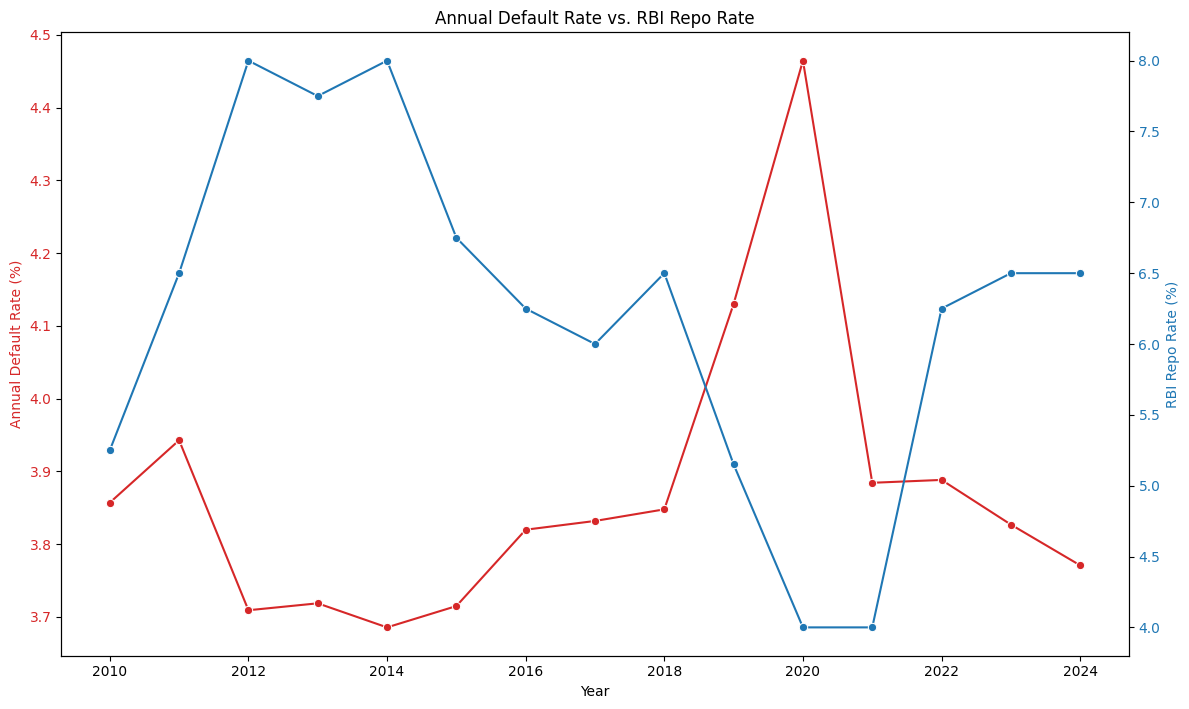

In [102]:
# Create a dual-axis line chart
fig, ax1 = plt.subplots(figsize=(12, 7))

color = 'tab:red'
ax1.set_xlabel('Year')
ax1.set_ylabel('Annual Default Rate (%)', color=color)
sns.lineplot(x='year', y='default_rate', data=annual_data, marker='o', ax=ax1, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('RBI Repo Rate (%)', color=color)
sns.lineplot(x='year', y='rbi_repo_rate_pct', data=annual_data, marker='o', ax=ax2, color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.title('Annual Default Rate vs. RBI Repo Rate')
plt.show()

Plot a histogram with KDE overlay for lgd_pct on defaulted loans only. Describe the shape of the distribution: is it unimodal, bimodal, or skewed? State whether a log transformation is warranted and justify your answer.

In [103]:
lgd_data = df_final[df_final['loan_status'] == 1]['lgd_pct']

In [106]:
np.log(lgd_data)

,lgd_pct
26,4.291691
28,1.950187
94,3.150597
99,3.869742
115,3.974810
...,...
1999934,3.852273
1999944,3.892636
1999972,3.152736
1999978,3.371768


Produce a scatter plot of cibil_score vs. lgd_pct with a fitted regression line. Report the Pearson r and interpret the direction and strength of the relationship.

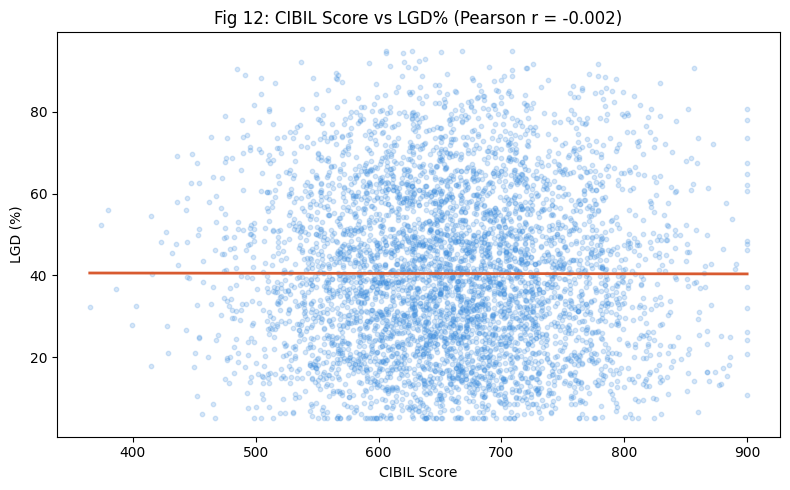

Pearson r=-0.0018, p=8.9975e-01


In [118]:
SEED = 42 # Defining SEED for reproducibility
def_df_plot = df_final[df_final['loan_status']==1][['cibil_score','lgd_pct']].dropna()
sample = def_df_plot.sample(min(5000, len(def_df_plot)), random_state=SEED)
fig, ax = plt.subplots(figsize=(8,5))
ax.scatter(sample['cibil_score'], sample['lgd_pct'], alpha=0.2, s=10, color='#378ADD')
m, b = np.polyfit(sample['cibil_score'], sample['lgd_pct'], 1)
xs = np.linspace(sample['cibil_score'].min(), sample['cibil_score'].max(), 100)
ax.plot(xs, m*xs+b, color='#D85A30', linewidth=2)
r, p = scipy.stats.pearsonr(sample['cibil_score'], sample['lgd_pct'])
ax.set_title(f'Fig 12: CIBIL Score vs LGD% (Pearson r = {r:.3f})')
ax.set_xlabel('CIBIL Score'); ax.set_ylabel('LGD (%)')
plt.tight_layout(); plt.show()
print(f"Pearson r={r:.4f}, p={p:.4e}")

# PHASE -03

(a)	Construct the following four repayment-burden features and for each report the correlation with lgd_pct:  emi_to_income_ratio  =  installment_inr ÷ (annual_inc_inr ÷ 12)  loan_to_income_ratio  =  loan_amnt_inr ÷ annual_inc_inr  rate_spread_pct  =  int_rate_pct − rbi_repo_rate_pct  real_interest_rate  =  int_rate_pct − cpi_inflation_pctWhich single feature shows the strongest correlation with the target?	(5)



EMI to Income Ratio

In [119]:
df_final['emi_to_income_ratio'] = df_final['installment_inr'] / (df_final['annual_inc_inr'] / 12)

In [120]:
df_final['emi_to_income_ratio'].describe()

,emi_to_income_ratio
count,1.959934e+06
mean,1.012150e+01
std,4.374243e-01
min,8.506721e+00
25%,9.804439e+00
50%,1.010171e+01
75%,1.041855e+01
max,1.231850e+01


In [121]:
df_final['emi_to_income_ratio'].corr(df_final['lgd_pct'])

np.float64(0.009430847454871457)

 Loan to Income Ratio

In [123]:
df_final['loan_to_income_ratio'] = df_final['loan_amnt_inr'] / df_final['annual_inc_inr']

In [124]:
df_final['loan_to_income_ratio'].describe()

,loan_to_income_ratio
count,1.959934e+06
mean,5.729907e+04
std,5.088884e+04
min,1.736214e+04
25%,2.458552e+04
50%,4.159109e+04
75%,7.038968e+04
max,1.949844e+06


In [125]:
df_final['loan_to_income_ratio'].corr(df_final['lgd_pct'])

np.float64(0.0014723916911712934)

Rate Spread

In [126]:
df_final['rate_spread_pct'] = df_final['int_rate_pct'] - df_final['rbi_repo_rate_pct']

In [127]:
df_final['rate_spread_pct'].describe()

,rate_spread_pct
count,2.000000e+06
mean,7.424294e+00
std,4.524040e+00
min,-1.000000e+00
25%,3.920000e+00
50%,6.770000e+00
75%,1.042000e+01
max,2.400000e+01


In [129]:
df_final['rate_spread_pct'].corr(df_final['lgd_pct'])

np.float64(0.07945813841109502)

Real Interest Rate

In [130]:
df_final['real_interest_rate'] = df_final['int_rate_pct'] - df_final['cpi_inflation_pct']

In [131]:
df_final['real_interest_rate'].describe()

,real_interest_rate
count,2.000000e+06
mean,7.639754e+00
std,4.809165e+00
min,-3.900000e+00
25%,4.150000e+00
50%,7.110000e+00
75%,1.081000e+01
max,2.460000e+01


In [132]:
df_final['real_interest_rate'].corr(df_final['lgd_pct'])

np.float64(0.07342905041075624)

In [133]:
features = [
    'emi_to_income_ratio',
    'loan_to_income_ratio',
    'rate_spread_pct',
    'real_interest_rate'
]

for f in features:
    print(f, df_final[f].corr(df_final['lgd_pct']))

emi_to_income_ratio 0.009430847454871457
loan_to_income_ratio 0.0014723916911712934
rate_spread_pct 0.07945813841109502
real_interest_rate 0.07342905041075624


Construct the following three bureau-behaviour features:  credit_util_composite  =  0.5×revol_util + 0.3×bc_util + 0.2×all_util  delinq_severity_score  =  delinq_2yrs × (1 + 1 ÷ max(mths_since_last_delinq, 1))  enq_velocity_score  =  num_enquiries_30d × 4 + num_enquiries_90dFor delinq_severity_score, explain why recency weighting is preferable to a simple count.

In [135]:
# 1. Credit Utilization Composite
df_final['credit_util_composite'] = (
    0.5 * df_final['revol_util_pct'] +
    0.3 * df_final['bc_util_pct'] +
    0.2 * df_final['il_util_pct']
)

In [136]:
# 2. Delinquency Severity Score
df_final['delinq_severity_score'] = (
    df_final['delinq_2yrs'] *
    (1 + 1 / df_final['mths_since_last_delinq'].clip(lower=1))

    )

In [137]:
# 3. Enquiry Velocity Score
df_final['enq_velocity_score'] = (
    df_final['num_enquiries_30d'] * 4 +
    df_final['num_enquiries_90d']
)

In [138]:
df_final[['credit_util_composite',
          'delinq_severity_score',
          'enq_velocity_score']].describe()

,credit_util_composite,delinq_severity_score,enq_velocity_score
count,1.539562e+06,856170.000000,2.000000e+06
mean,4.199539e+01,2.582598,8.246155e+00
std,1.227105e+01,1.815427,7.912270e+00
min,3.960000e+00,1.043478,0.000000e+00
25%,3.308000e+01,1.090909,2.000000e+00
50%,4.150000e+01,2.111111,6.000000e+00
75%,5.044000e+01,3.300000,1.200000e+01
max,9.354000e+01,14.000000,3.900000e+01


In [139]:
print("credit_util_composite:", df_final['credit_util_composite'].corr(df_final['lgd_pct']))
print("delinq_severity_score:", df_final['delinq_severity_score'].corr(df_final['lgd_pct']))
print("enq_velocity_score:", df_final['enq_velocity_score'].corr(df_final['lgd_pct']))

credit_util_composite: 0.004283426369834743
delinq_severity_score: 2.7679775426697666e-05
enq_velocity_score: 0.0004905991914158988


Construct the following three income and collateral features:  income_stability_ratio  =  annual_inc_inr ÷ (emp_length_years + 1)  credit_depth_score  =  total_acc ÷ (credit_hist_years + 1)  collateral_coverage_ratio  =  collateral_value_inr ÷ (loan_amnt_inr + 1)Explain in business terms what a high collateral_coverage_ratio implies for Loss Given Default.

In [140]:
# 1. Income Stability Ratio
df_final['income_stability_ratio'] = (
    df_final['annual_inc_inr'] /
    (df_final['emp_length_years'] + 1)
)

In [141]:
# 2. Credit Depth Score
df_final['credit_depth_score'] = (
    df_final['total_acc'] /
    (df_final['credit_hist_years'] + 1)
)

In [142]:
# 3. Collateral Coverage Ratio
df_final['collateral_coverage_ratio'] = (
    df_final['collateral_value_inr'] /
    (df_final['loan_amnt_inr'] + 1)
)

In [143]:
df_final[['income_stability_ratio',
          'credit_depth_score',
          'collateral_coverage_ratio']].describe()

,income_stability_ratio,credit_depth_score,collateral_coverage_ratio
count,1.782986e+06,2.000000e+06,2.000000e+06
mean,7.108492e-01,2.072199e+00,8.719186e-06
std,5.785716e-01,1.948919e+00,1.576469e-05
min,7.018786e-02,2.857143e-02,0.000000e+00
25%,2.817455e-01,9.064422e-01,0.000000e+00
50%,5.088221e-01,1.420651e+00,0.000000e+00
75%,9.635678e-01,2.463054e+00,1.254543e-05
max,2.844999e+00,1.766667e+01,5.774272e-05


In [144]:
print("income_stability_ratio:", df_final['income_stability_ratio'].corr(df_final['lgd_pct']))
print("credit_depth_score:", df_final['credit_depth_score'].corr(df_final['lgd_pct']))
print("collateral_coverage_ratio:", df_final['collateral_coverage_ratio'].corr(df_final['lgd_pct']))

income_stability_ratio: 6.55614747210597e-05
credit_depth_score: 5.45264176128096e-05
collateral_coverage_ratio: -0.0003229194003863952


Apply log(1 + x) transformation to annual_inc_inr and loan_amnt_inr to create log_annual_inc and log_loan_amnt. Report the skewness of each variable before and after transformation. Explain why reducing skewness matters for OLS regression assumptions.

In [149]:
skew_df = pd.DataFrame({
    'Feature': ['annual_inc_inr','loan_amnt_inr'],
    'Before': [
        df_final['annual_inc_inr'].skew(),
        df_final['loan_amnt_inr'].skew()
    ],
    'After': [
        df_final['log_annual_inc'].skew(),
        df_final['log_loan_amnt'].skew()
    ]
})

print(skew_df)

          Feature    Before     After
0  annual_inc_inr  0.195505  0.160196
1   loan_amnt_inr  3.651117  0.581627


Create a binary covid_issue_year_flag equal to 1 for loans issued in 2020. Present a grouped summary showing mean lgd_pct for covid_issue_year_flag = 0 vs. 1. Is the difference statistically significant? Run an independent-samples t-test and report the p-value.

In [150]:
df_final['covid_issue_year_flag'] = (df_final['issue_year'] == 2020).astype(int)

In [151]:
covid_summary = df_final.groupby('covid_issue_year_flag')['lgd_pct'].mean().reset_index()
covid_summary.columns = ['covid_flag', 'mean_lgd']

print(covid_summary)

   covid_flag  mean_lgd
0           0  1.537543
1           1  1.793456


In [152]:
from scipy.stats import ttest_ind

group0 = df_final[df_final['covid_issue_year_flag'] == 0]['lgd_pct']
group1 = df_final[df_final['covid_issue_year_flag'] == 1]['lgd_pct']

t_stat, p_value = ttest_ind(group0, group1, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -9.980718639770577
P-value: 1.880969520345083e-23


PHASE -04

(a)	Compute Variance Inflation Factors (VIF) for all candidate features. Present the full VIF table. Drop any feature with VIF > 10 and justify each removal decision. State the final list of features retained for modelling.	(4)



In [153]:
df_model = df_final[df_final['loan_status'] == 1].copy(

)

In [154]:
drop_cols = [
    'total_pymnt', 'recoveries',
    'collection_recovery_fee', 'collections_12mths_fee',
    'net_loss_inr'
]

df_model = df_model.drop(columns=[col for col in drop_cols if col in df_model.columns])


In [155]:
df_num = df_model.select_dtypes(include=['int64','float64']).dropna()

In [158]:
X = df_num

In [159]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = X.fillna(0)

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_data = vif_data.sort_values(by="VIF", ascending=False)

print(vif_data)

                      Feature           VIF
0             installment_inr           inf
13         total_emi_paid_inr           inf
14            emi_overdue_inr           inf
11        installment_due_inr           inf
12          total_emi_due_inr           inf
22          total_rec_int_inr           inf
21        total_rec_prncp_inr           inf
19            total_pymnt_inr           inf
32             log_annual_inc  4.818812e+06
4              annual_inc_inr  4.811272e+06
18        emi_to_income_ratio  9.966092e+05
28       loan_to_income_ratio  6.711503e+03
24              out_prncp_inr  6.462573e+03
25          out_prncp_inv_inr  4.653806e+03
20        total_pymnt_inv_inr  4.470946e+03
5               revol_bal_inr  1.348250e+03
10              provision_inr  8.024605e+02
6        total_rev_hi_lim_inr  4.615763e+02
7             avg_cur_bal_inr  4.153500e+02
8              recoveries_inr  7.729889e+01
29      credit_util_composite  1.281842e+01
26   chargeoff_within_12_mths  8

In [160]:
high_vif = vif_data[vif_data["VIF"] > 10]["Feature"]

print("Features to drop:", list(high_vif))

X_final = X.drop(columns=high_vif)

Features to drop: ['installment_inr', 'total_emi_paid_inr', 'emi_overdue_inr', 'installment_due_inr', 'total_emi_due_inr', 'total_rec_int_inr', 'total_rec_prncp_inr', 'total_pymnt_inr', 'log_annual_inc', 'annual_inc_inr', 'emi_to_income_ratio', 'loan_to_income_ratio', 'out_prncp_inr', 'out_prncp_inv_inr', 'total_pymnt_inv_inr', 'revol_bal_inr', 'provision_inr', 'total_rev_hi_lim_inr', 'avg_cur_bal_inr', 'recoveries_inr', 'credit_util_composite']


(b)	Fit a baseline OLS model using statsmodels. Print the full model summary. Interpret: R², Adjusted R², F-statistic (with p-value), Durbin-Watson statistic, Jarque-Bera test result, and Condition Number. For the five largest-magnitude coefficients, provide a one-sentence business translation of each.	(6)



In [162]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

# lgd_pct is the target — select retained features + target together
model_df = df_model[X_final.columns.tolist() + ['lgd_pct']].dropna()
print(f"Modelling rows: {len(model_df):,}")

X = model_df[X_final.columns.tolist()]
y = model_df['lgd_pct']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

ols = sm.OLS(y_train, sm.add_constant(X_train)).fit()
print(ols.summary())

Modelling rows: 64,811
                            OLS Regression Results                            
Dep. Variable:                lgd_pct   R-squared:                       0.221
Model:                            OLS   Adj. R-squared:                  0.220
Method:                 Least Squares   F-statistic:                     1334.
Date:                Sun, 07 Jun 2026   Prob (F-statistic):               0.00
Time:                        13:25:26   Log-Likelihood:            -2.2241e+05
No. Observations:               51848   AIC:                         4.448e+05
Df Residuals:                   51836   BIC:                         4.449e+05
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------

Fit Ridge, Lasso, and ElasticNet models using GridSearchCV with 5-fold cross-validation. For each: report the optimal alpha, cross-validated RMSE, and test-set R². Present a side-by-side comparison table. List all features that Lasso reduced to exactly zero and comment on what their exclusion implies.

In [173]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

# Use model_df which was correctly prepared with X_final features and lgd_pct
X = model_df[X_final.columns.tolist()]
y = model_df['lgd_pct']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=20
)

In [170]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [174]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

ridge = Ridge()

param_grid = {'alpha': np.logspace(-3, 3, 20)}

ridge_cv = GridSearchCV(ridge, param_grid, cv=5, scoring='neg_root_mean_squared_error')
ridge_cv.fit(X_train_scaled, y_train)

ridge_best = ridge_cv.best_estimator_

ridge_pred = ridge_best.predict(X_test_scaled)

ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_r2 = r2_score(y_test, ridge_pred)
ridge_alpha = ridge_cv.best_params_['alpha']

In [175]:
from sklearn.linear_model import Lasso

lasso = Lasso(max_iter=10000)

lasso_cv = GridSearchCV(lasso, param_grid, cv=5, scoring='neg_root_mean_squared_error')
lasso_cv.fit(X_train_scaled, y_train)

lasso_best = lasso_cv.best_estimator_

lasso_pred = lasso_best.predict(X_test_scaled)

lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))
lasso_r2 = r2_score(y_test, lasso_pred)
lasso_alpha = lasso_cv.best_params_['alpha']

In [176]:
from sklearn.linear_model import ElasticNet

param_grid_en = {
    'alpha': np.logspace(-3, 3, 10),
    'l1_ratio': [0.2, 0.5, 0.8]
}

en = ElasticNet(max_iter=10000)

en_cv = GridSearchCV(en, param_grid_en, cv=5, scoring='neg_root_mean_squared_error')
en_cv.fit(X_train_scaled, y_train)

en_best = en_cv.best_estimator_

en_pred = en_best.predict(X_test_scaled)

en_rmse = np.sqrt(mean_squared_error(y_test, en_pred))
en_r2 = r2_score(y_test, en_pred)
en_alpha = en_cv.best_params_['alpha']

In [178]:

results = pd.DataFrame({
    'Model': ['Ridge', 'Lasso', 'ElasticNet'],
    'Best Alpha': [ridge_alpha, lasso_alpha, en_alpha],
    'CV RMSE': [-ridge_cv.best_score_, -lasso_cv.best_score_, -en_cv.best_score_],
    'Test R2': [ridge_r2, lasso_r2, en_r2]
})

print(results)

        Model   Best Alpha    CV RMSE   Test R2
0       Ridge  1000.000000  20.046189 -0.000389
1       Lasso     0.335982  20.042620 -0.000033
2  ElasticNet     0.464159  20.042620 -0.000033


In [179]:
lasso_coef = pd.Series(lasso_best.coef_, index=X.columns)

zero_features = lasso_coef[lasso_coef == 0].index.tolist()

print("Dropped features:", zero_features)

Dropped features: ['covid_issue_year_flag', 'collateral_value_inr', 'prop_value_inr', 'hardship_amount_inr', 'emi_advance_paid_inr', 'penal_charges_inr', 'waiver_amount_inr', 'last_pymnt_amnt_inr', 'chargeoff_within_12_mths', 'expected_loss_inr', 'income_stability_ratio', 'collateral_coverage_ratio']


Produce a 4-panel diagnostic figure: (i) Residuals vs. Fitted, (ii) QQ Plot of residuals, (iii) Scale-Location, (iv) Cook's Distance. For each panel explicitly state which regression assumption it tests and whether that assumption is satisfied or violated in your model.

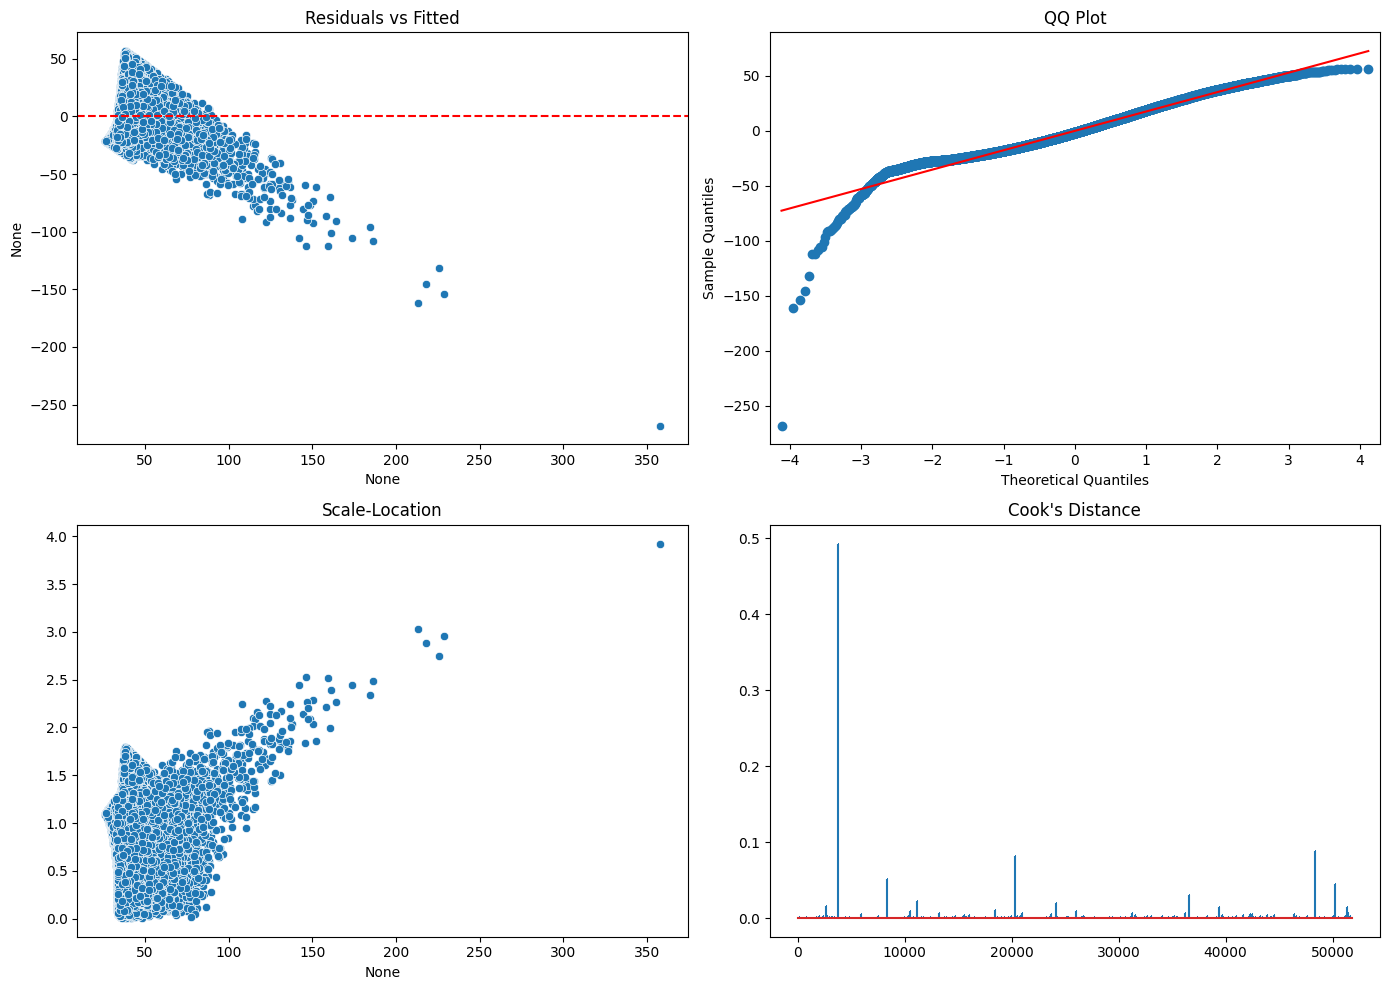

In [181]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.outliers_influence import OLSInfluence
import numpy as np

# Residuals & fitted for the OLS model
fitted = ols.fittedvalues
residuals = ols.resid
std_residuals = ols.get_influence().resid_studentized_internal

# Cook's distance for the OLS model
influence = OLSInfluence(ols)
cooks_d = influence.cooks_distance[0]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (i) Residuals vs Fitted
sns.scatterplot(x=fitted, y=residuals, ax=axes[0,0])
axes[0,0].axhline(0, color='red', linestyle='--')
axes[0,0].set_title("Residuals vs Fitted")

# (ii) QQ Plot
qqplot(residuals, line='s', ax=axes[0,1])
axes[0,1].set_title("QQ Plot")

# (iii) Scale-Location
sns.scatterplot(x=fitted, y=np.sqrt(np.abs(std_residuals)), ax=axes[1,0])
axes[1,0].set_title("Scale-Location")

# (iv) Cook's Distance
axes[1,1].stem(cooks_d, markerfmt=",")
axes[1,1].set_title("Cook's Distance")

plt.tight_layout()
plt.show()